# World Cup Penalty Shootout Analysis

This notebook analyzes penalty shootout data (`WorldCupShootouts.csv`) to answer:

1. Where do shooters place the ball, and which zones are most/least likely to result in a goal? (shot-zone heatmap, drawn as an actual goal)
2. Does the keeper's dive direction relative to the shot zone affect the outcome? (keeper-dive vs. shot-zone, drawn as three goals)
3. Which zone has the highest conversion rate for right-footed vs. left-footed shooters?
4. **How statistically significant are these findings, given how small some of the samples are?**

### Data dictionary

**Zone** — the goal divided into 9 sections, viewed face-on (as if standing behind the shooter looking at the goal):

| | Left | Center | Right |
|---|---|---|---|
| **Top** | 1 | 2 | 3 |
| **Middle** | 4 | 5 | 6 |
| **Bottom** | 7 | 8 | 9 |

**Keeper** — direction the goalkeeper dived, from the shooter's perspective: `L` = dove left, `C` = stayed center, `R` = dove right.

**Foot** — kicking foot: `L` = left-footed, `R` = right-footed.

**Goal** — 1 if the shot resulted in a goal, 0 otherwise.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy import stats

pd.set_option('display.precision', 3)
plt.rcParams['figure.dpi'] = 110


## Load the data

In [2]:
df_raw = pd.read_csv('WorldCupShootouts.csv')
print(df_raw.shape)
df_raw.head()


(304, 9)


,Game_id,Team,Zone,Foot,Keeper,OnTarget,Goal,Penalty_Number,Elimination
0,1,FRA,7.0,R,R,1.0,1.0,1,0.0
1,1,GER,9.0,R,C,1.0,1.0,2,0.0
2,1,FRA,6.0,R,L,1.0,1.0,3,0.0
3,1,GER,2.0,R,C,1.0,1.0,4,0.0
4,1,FRA,9.0,R,L,1.0,1.0,5,0.0


## Clean the data

25 of the 304 rows are missing `Zone`/`Foot`/`Keeper`/`OnTarget`/`Goal` (likely shots where these weren't recorded). We drop those for this analysis. There are also 2 rows where `Keeper` is lowercase `l` instead of `L` — we normalize casing.

In [3]:
df = df_raw.dropna(subset=['Zone', 'Foot', 'Keeper', 'OnTarget', 'Goal']).copy()
df['Zone'] = df['Zone'].astype(int)
df['Keeper'] = df['Keeper'].str.upper()
df['Goal'] = df['Goal'].astype(int)

print(f"Rows kept: {len(df)} of {len(df_raw)}")
df['Keeper'].value_counts()


Rows kept: 279 of 304


Keeper
L    129
R    114
C     36
Name: count, dtype: int64

## Helper: draw a shot zone grid as an actual goal

Real soccer goals are 8 yards (24 ft) wide by 8 ft high — a 3:1 width-to-height ratio, much wider and flatter than a square grid. The function below draws the 9 zones at that real proportion, with a crossbar/posts, a net texture, and grass behind it, instead of a plain colored grid.

In [4]:
GOAL_W, GOAL_H = 3.0, 1.0  # real-world ratio: 24ft x 8ft = 3:1

def draw_goal(ax, values, counts=None, cmap_name='RdYlGn', fmt='{:.0%}', value_label='Conversion rate',
              vmin=None, vmax=None, show_colorbar=True, min_n_dim=None):
    """Draw a 3x3 grid of values (zones 1-9, row-major: top row 1,2,3 ... bottom row 7,8,9)
    as colored regions inside a soccer goal shape."""
    grid = np.array(values, dtype=float).reshape(3, 3)
    cgrid = np.array(counts, dtype=float).reshape(3, 3) if counts is not None else np.full((3, 3), np.nan)
    finite = grid[~np.isnan(grid)]
    vmin = (np.nanmin(finite) if len(finite) else 0) if vmin is None else vmin
    vmax = (np.nanmax(finite) if len(finite) else 1) if vmax is None else vmax
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    # grass + sky backdrop
    ax.add_patch(patches.Rectangle((-0.35, -0.45), GOAL_W + 0.7, 0.45, facecolor='#6fae4a', edgecolor='none', zorder=0))
    ax.add_patch(patches.Rectangle((-0.35, -0.02), GOAL_W + 0.7, GOAL_H + 0.6, facecolor='#dff0e8', edgecolor='none', zorder=0))

    pad = 0.015
    cell_w, cell_h = GOAL_W / 3, GOAL_H / 3
    for i in range(3):
        for j in range(3):
            zone_num = i * 3 + j + 1
            val = grid[i, j]
            n = cgrid[i, j]
            x0, y0 = j * cell_w, GOAL_H - (i + 1) * cell_h
            low_n = min_n_dim is not None and (not np.isnan(n)) and n < min_n_dim
            color = cmap(norm(val)) if not np.isnan(val) else (0.85, 0.85, 0.85, 1)
            alpha = 0.4 if low_n else 0.85
            ax.add_patch(patches.Rectangle((x0 + pad, y0 + pad), cell_w - 2 * pad, cell_h - 2 * pad,
                                            facecolor=color, edgecolor='none', alpha=alpha, zorder=1))
            if np.isnan(val):
                label = f"{zone_num}\nn/a"
            elif counts is not None:
                label = f"{zone_num}\n{fmt.format(val)}\n(n={int(n)})"
            else:
                label = f"{zone_num}\n{fmt.format(val)}"
            ax.text(x0 + cell_w / 2, y0 + cell_h / 2, label, ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color='#1a1a1a', zorder=4)

    # net texture
    step = 0.12
    for x in np.arange(0, GOAL_W + step, step):
        ax.plot([x, x], [0, GOAL_H], color='white', linewidth=0.4, alpha=0.55, zorder=2)
    for y in np.arange(0, GOAL_H + step, step):
        ax.plot([0, GOAL_W], [y, y], color='white', linewidth=0.4, alpha=0.55, zorder=2)

    # zone divider lines
    for x in [cell_w, 2 * cell_w]:
        ax.plot([x, x], [0, GOAL_H], color='white', linewidth=1.3, linestyle=(0, (3, 2)), zorder=3)
    for y in [cell_h, 2 * cell_h]:
        ax.plot([0, GOAL_W], [y, y], color='white', linewidth=1.3, linestyle=(0, (3, 2)), zorder=3)

    # goalposts + crossbar
    ax.add_patch(patches.Rectangle((0, 0), GOAL_W, GOAL_H, fill=False, edgecolor='black', linewidth=6.5, zorder=5))
    ax.add_patch(patches.Rectangle((0, 0), GOAL_W, GOAL_H, fill=False, edgecolor='white', linewidth=3.5, zorder=6))

    ax.set_xlim(-0.35, GOAL_W + 0.35)
    ax.set_ylim(-0.45, GOAL_H + 0.15)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_colorbar:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.05, orientation='horizontal')
        cbar.set_label(value_label, fontsize=8)


## 1. Shot-zone heatmap, drawn as a real goal

Shot frequency (where shooters actually aim) and conversion rate (how often that zone results in a goal), at true goal proportions (3:1 wide) with posts, net, and grass.

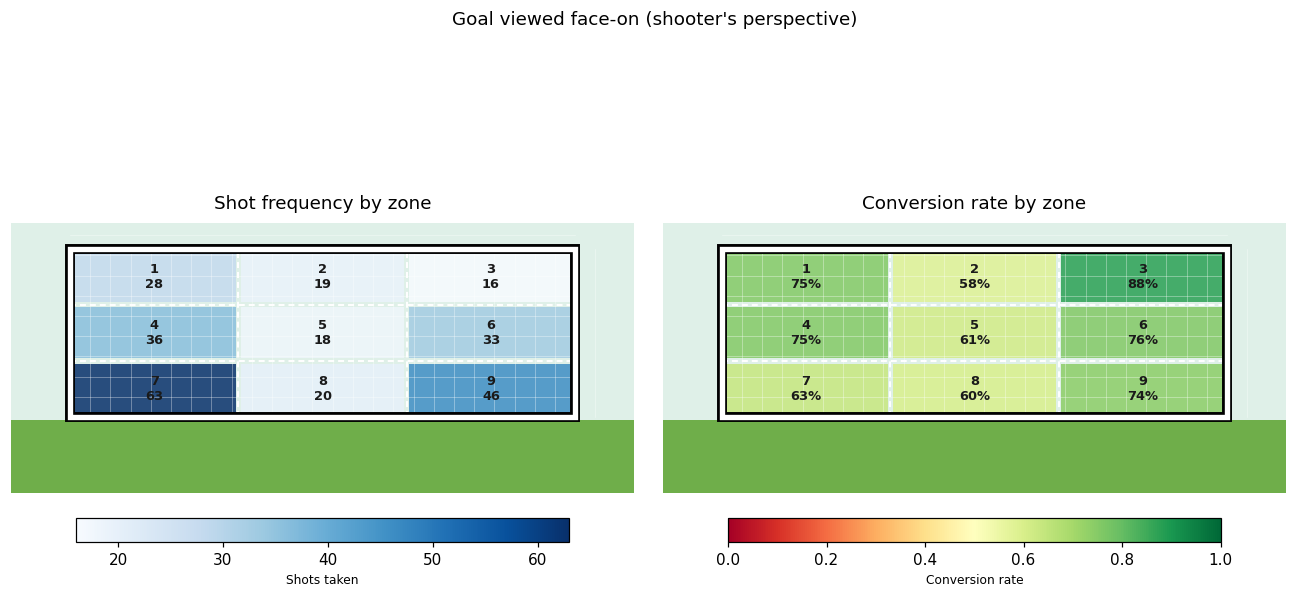

,count,conversion
Zone,,
1,28,0.750
2,19,0.579
3,16,0.875
4,36,0.750
5,18,0.611
6,33,0.758
7,63,0.635
8,20,0.600
9,46,0.739


In [5]:
zone_stats = df.groupby('Zone')['Goal'].agg(count='count', conversion='mean').reindex(range(1, 10))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
draw_goal(axes[0], zone_stats['count'].values, cmap_name='Blues', fmt='{:.0f}', value_label='Shots taken')
axes[0].set_title('Shot frequency by zone', fontsize=12, pad=10)
draw_goal(axes[1], zone_stats['conversion'].values, cmap_name='RdYlGn', fmt='{:.0%}', value_label='Conversion rate', vmin=0, vmax=1)
axes[1].set_title('Conversion rate by zone', fontsize=12, pad=10)
plt.suptitle("Goal viewed face-on (shooter's perspective)", y=0.98)
plt.tight_layout()
plt.show()

zone_stats


## 2. Keeper dive direction vs. shot zone, as three goals

One goal diagram per keeper dive direction, showing the conversion rate for shots landing in each zone when the keeper went that way. Faded cells have fewer than 3 shots — read those numbers as anecdotal, not reliable.

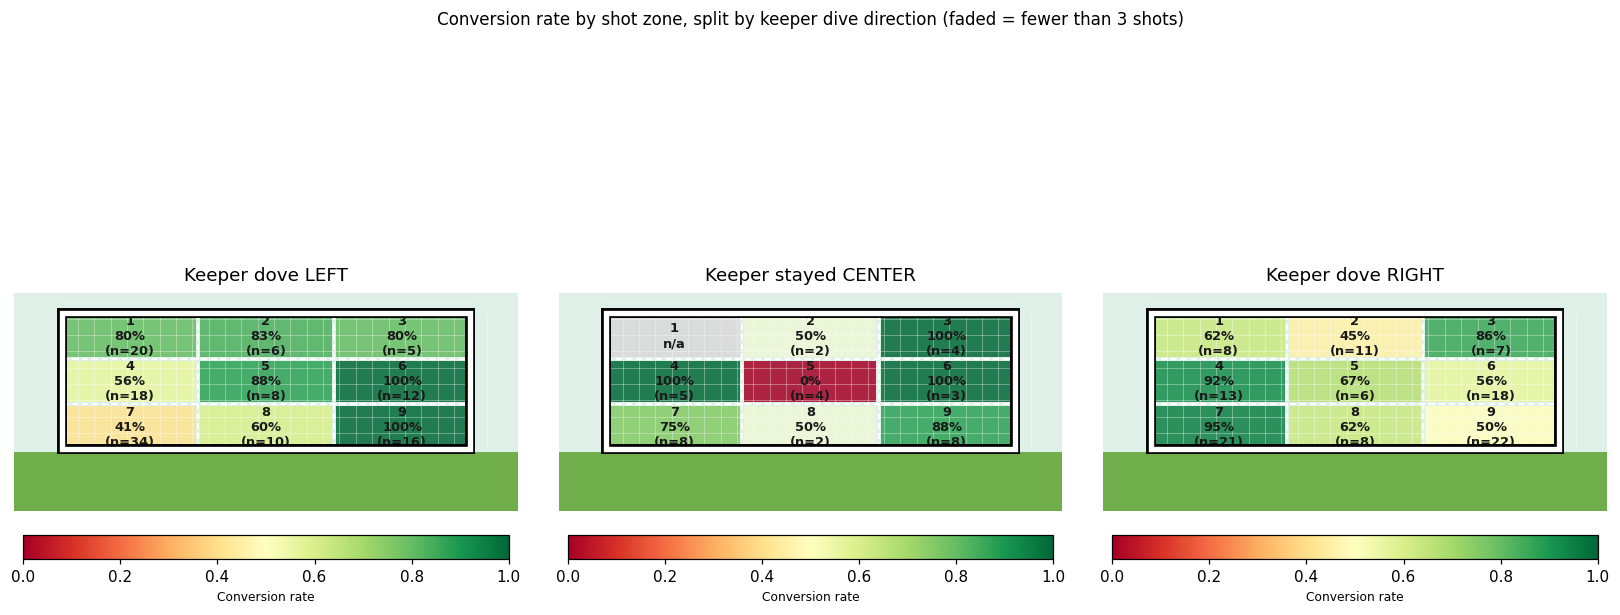

In [6]:
keeper_zone = df.pivot_table(index='Keeper', columns='Zone', values='Goal', aggfunc='mean').reindex(['L', 'C', 'R']).reindex(columns=range(1, 10))
keeper_zone_n = df.pivot_table(index='Keeper', columns='Zone', values='Goal', aggfunc='count').reindex(['L', 'C', 'R']).reindex(columns=range(1, 10))

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
titles = {'L': 'Keeper dove LEFT', 'C': 'Keeper stayed CENTER', 'R': 'Keeper dove RIGHT'}
for ax, k in zip(axes, ['L', 'C', 'R']):
    draw_goal(ax, keeper_zone.loc[k].values, keeper_zone_n.loc[k].values, cmap_name='RdYlGn', fmt='{:.0%}',
              value_label='Conversion rate', vmin=0, vmax=1, min_n_dim=3)
    ax.set_title(titles[k], fontsize=12, pad=8)
plt.suptitle("Conversion rate by shot zone, split by keeper dive direction (faded = fewer than 3 shots)", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


## 3. Conversion rate by zone, split by kicking foot

In [7]:
foot_zone = df.groupby(['Foot', 'Zone'])['Goal'].agg(conversion='mean', attempts='count').reset_index()
foot_zone_sorted = foot_zone.sort_values(['Foot', 'conversion'], ascending=[True, False])

for foot, label in [('L', 'Left-footed'), ('R', 'Right-footed')]:
    sub = foot_zone_sorted[foot_zone_sorted['Foot'] == foot]
    print(f"--- {label} shooters (all zones, sorted by conversion rate) ---")
    print(sub[['Zone', 'conversion', 'attempts']].to_string(index=False))
    print()


--- Left-footed shooters (all zones, sorted by conversion rate) ---
 Zone  conversion  attempts
    3       1.000         5
    5       1.000         3
    4       0.750         8
    1       0.667         3
    9       0.667        12
    6       0.600         5
    7       0.600        10
    2       0.500         2
    8       0.500         8

--- Right-footed shooters (all zones, sorted by conversion rate) ---
 Zone  conversion  attempts
    3       0.818        11
    6       0.786        28
    9       0.765        34
    1       0.760        25
    4       0.750        28
    8       0.667        12
    7       0.642        53
    2       0.588        17
    5       0.533        15



In [8]:
MIN_ATTEMPTS = 10

print("Highest conversion rate (any sample size):")
best_raw = foot_zone.loc[foot_zone.groupby('Foot')['conversion'].idxmax()]
print(best_raw[['Foot', 'Zone', 'conversion', 'attempts']].to_string(index=False))

print(f"\nHighest conversion rate among zones with >= {MIN_ATTEMPTS} attempts:")
reliable = foot_zone[foot_zone['attempts'] >= MIN_ATTEMPTS]
best_reliable = reliable.loc[reliable.groupby('Foot')['conversion'].idxmax()]
print(best_reliable[['Foot', 'Zone', 'conversion', 'attempts']].to_string(index=False))


Highest conversion rate (any sample size):
Foot  Zone  conversion  attempts
   L     3       1.000         5
   R     3       0.818        11

Highest conversion rate among zones with >= 10 attempts:
Foot  Zone  conversion  attempts
   L     9       0.667        12
   R     3       0.818        11


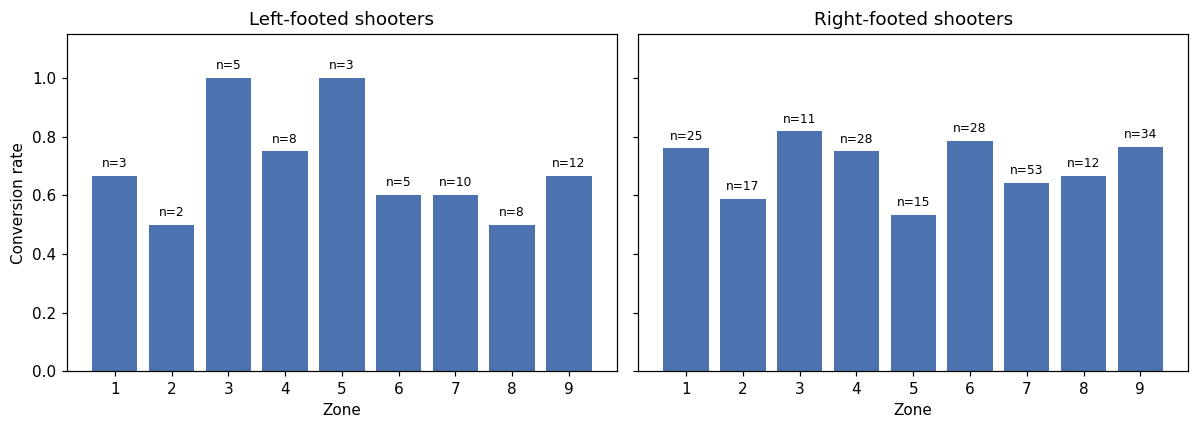

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (foot, label) in zip(axes, [('L', 'Left-footed'), ('R', 'Right-footed')]):
    sub = foot_zone[foot_zone['Foot'] == foot].sort_values('Zone')
    bars = ax.bar(sub['Zone'].astype(str), sub['conversion'], color='#4C72B0')
    for bar, n in zip(bars, sub['attempts']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"n={int(n)}",
                ha='center', va='bottom', fontsize=8)
    ax.set_title(f"{label} shooters")
    ax.set_xlabel('Zone')
    ax.set_ylim(0, 1.15)
axes[0].set_ylabel('Conversion rate')
plt.tight_layout()
plt.show()


## 4. How statistically significant is any of this?

Every conversion rate above is a proportion estimated from a small sample — some zone/foot/keeper combinations have as few as 2-5 shots. A single extra goal or miss can swing those rates by 10-30 percentage points. Before trusting "Zone X is best," we need to know whether the differences we're seeing could plausibly be due to chance.

We use two tools:
- **Wilson score 95% confidence intervals** on each proportion — a range of plausible true conversion rates given the sample size, more reliable than a plain error bar when n is small or the rate is near 0%/100%.
- **Chi-square / two-proportion z-tests** — to test whether an observed difference is larger than what random noise alone would produce.

In [10]:
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return ((center - margin) / denom, (center + margin) / denom)

zone_ci = df.groupby('Zone')['Goal'].agg(successes='sum', n='count').reindex(range(1, 10))
zone_ci['conversion'] = zone_ci['successes'] / zone_ci['n']
zone_ci[['ci_low', 'ci_high']] = zone_ci.apply(lambda r: wilson_ci(r['successes'], r['n']), axis=1, result_type='expand')
zone_ci


,successes,n,conversion,ci_low,ci_high
Zone,,,,,
1,21,28,0.750,0.566,0.873
2,11,19,0.579,0.363,0.769
3,14,16,0.875,0.640,0.965
4,27,36,0.750,0.589,0.862
5,11,18,0.611,0.386,0.797
6,25,33,0.758,0.590,0.872
7,40,63,0.635,0.511,0.743
8,12,20,0.600,0.387,0.781
9,34,46,0.739,0.597,0.844


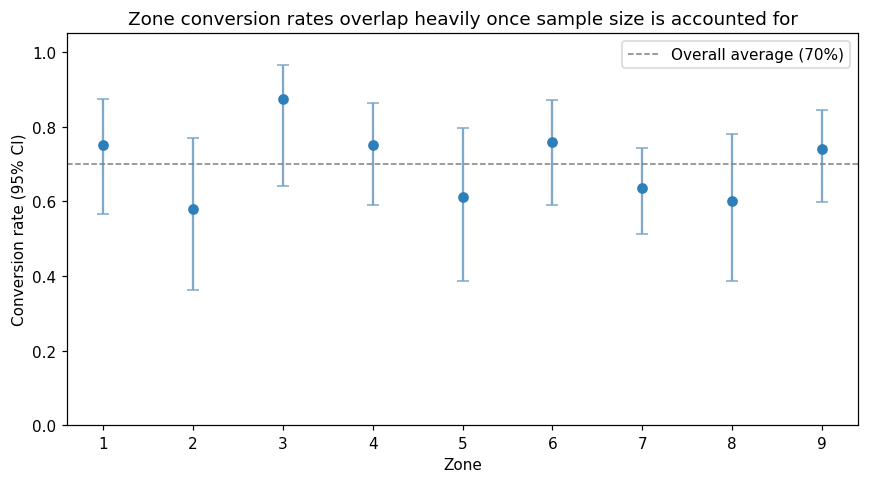

Chi-square test, Zone vs Goal: chi2=8.16, dof=8, p=0.418
(Smallest expected cell count: 4.8 -- below 5 means the test itself is on shaky ground)


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
zones = zone_ci.index
ax.errorbar(zones, zone_ci['conversion'],
            yerr=[zone_ci['conversion'] - zone_ci['ci_low'], zone_ci['ci_high'] - zone_ci['conversion']],
            fmt='o', capsize=4, color='#2c7fb8', ecolor='#7fa8c9')
ax.axhline(df['Goal'].mean(), color='gray', linestyle='--', linewidth=1, label=f"Overall average ({df['Goal'].mean():.0%})")
ax.set_xticks(zones)
ax.set_xlabel('Zone')
ax.set_ylabel('Conversion rate (95% CI)')
ax.set_title('Zone conversion rates overlap heavily once sample size is accounted for')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

# Global test: is conversion rate actually different across zones at all?
ct_zone = pd.crosstab(df['Zone'], df['Goal'])
chi2, p, dof, expected = stats.chi2_contingency(ct_zone)
print(f"Chi-square test, Zone vs Goal: chi2={chi2:.2f}, dof={dof}, p={p:.3f}")
print(f"(Smallest expected cell count: {expected.min():.1f} -- below 5 means the test itself is on shaky ground)")


**Result:** the 95% confidence intervals for every zone overlap substantially, and the chi-square test comparing all 9 zones gives **p = 0.42** — nowhere near the conventional 0.05 significance threshold. In plain terms: **we cannot statistically distinguish the 9 zones' conversion rates from each other with this sample.** Zone 3 looks best at 88%, but its interval (64%-97%, n=16) overlaps every other zone's interval. Treat the zone ranking as descriptive, not proof that some zones are truly easier to score from.

In [12]:
# Does keeper dive direction alone (L/C/R) predict outcome?
ct_keeper = pd.crosstab(df['Keeper'], df['Goal'])
chi2k, pk, dofk, expk = stats.chi2_contingency(ct_keeper)
print("Conversion by keeper dive direction alone:")
print(ct_keeper)
print(f"\nChi-square test, Keeper vs Goal: chi2={chi2k:.2f}, dof={dofk}, p={pk:.3f}")


Conversion by keeper dive direction alone:
Goal     0   1
Keeper        
C        9  27
L       39  90
R       36  78

Chi-square test, Keeper vs Goal: chi2=0.56, dof=2, p=0.754


**Result: p = 0.75.** Which way the keeper dives, by itself, tells us almost nothing about whether the shot goes in. That makes sense — diving direction only matters *relative to where the shot goes*, which is exactly the next test.

                    successes    n  conversion  ci_low  ci_high
KeeperGuessedRight                                             
False                     126  152       0.829   0.761    0.881
True                       69  127       0.543   0.457    0.627

Chi-square test, keeper-guessed-right vs Goal: chi2=25.49, dof=1, p=4.45e-07


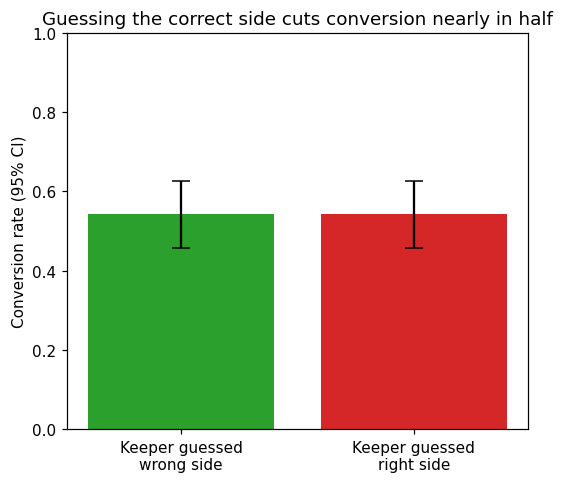

In [13]:
# The test that matters: did the keeper guess the correct side?
side_map = {1: 'L', 4: 'L', 7: 'L', 2: 'C', 5: 'C', 8: 'C', 3: 'R', 6: 'R', 9: 'R'}
df['ShotSide'] = df['Zone'].map(side_map)
df['KeeperGuessedRight'] = df['Keeper'] == df['ShotSide']

match_stats = df.groupby('KeeperGuessedRight')['Goal'].agg(successes='sum', n='count')
match_stats['conversion'] = match_stats['successes'] / match_stats['n']
match_stats[['ci_low', 'ci_high']] = match_stats.apply(lambda r: wilson_ci(r['successes'], r['n']), axis=1, result_type='expand')
print(match_stats)

ct_match = pd.crosstab(df['KeeperGuessedRight'], df['Goal'])
chi2m, pm, dofm, expm = stats.chi2_contingency(ct_match)
print(f"\nChi-square test, keeper-guessed-right vs Goal: chi2={chi2m:.2f}, dof={dofm}, p={pm:.2e}")

fig, ax = plt.subplots(figsize=(5, 4.5))
labels = ['Keeper guessed\nwrong side', 'Keeper guessed\nright side']
vals = match_stats.loc[[False, True], 'conversion'].values
errs_low = vals - match_stats.loc[[False, True], 'ci_low'].values
errs_high = match_stats.loc[[False, True], 'ci_high'].values - vals
ax.bar(labels, vals, color=['#2ca02c', '#d62728'], yerr=[errs_low, errs_high], capsize=6)
ax.set_ylabel('Conversion rate (95% CI)')
ax.set_ylim(0, 1)
ax.set_title('Guessing the correct side cuts conversion nearly in half')
plt.tight_layout()
plt.show()


**Result: this one is real.** When the keeper dives to the same side as the shot, conversion drops to ~54% (95% CI roughly 46%-63%, n=127); when the keeper guesses wrong, conversion jumps to ~83% (95% CI roughly 76%-88%, n=152). Chi-square p ≈ 4.5e-7 — this is a highly significant, well-powered result (unlike the zone-by-zone breakdown, both groups here have well over 100 shots). This is the one finding in the notebook that holds up statistically: **guessing the correct side is the single biggest driver of penalty-save probability in this dataset**, far more than shot placement alone.

In [14]:
# Overall conversion rate: left-footed vs right-footed shooters
foot_stats = df.groupby('Foot')['Goal'].agg(successes='sum', n='count')
foot_stats['conversion'] = foot_stats['successes'] / foot_stats['n']
foot_stats[['ci_low', 'ci_high']] = foot_stats.apply(lambda r: wilson_ci(r['successes'], r['n']), axis=1, result_type='expand')
print(foot_stats)

s = foot_stats['successes'].values
n = foot_stats['n'].values
p_pool = s.sum() / n.sum()
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n[0] + 1 / n[1]))
z = (s[0] / n[0] - s[1] / n[1]) / se
p_val = 2 * (1 - stats.norm.cdf(abs(z)))
print(f"\nTwo-proportion z-test, Left- vs Right-footed overall conversion: z={z:.2f}, p={p_val:.3f}")


      successes    n  conversion  ci_low  ci_high
Foot                                             
L            38   56       0.679   0.548    0.786
R           157  223       0.704   0.641    0.760

Two-proportion z-test, Left- vs Right-footed overall conversion: z=-0.37, p=0.710


**Result: p = 0.71.** No evidence that left-footed and right-footed shooters convert penalties at different overall rates (68% vs 70%). And within each foot, the per-zone breakdowns from Section 3 have even smaller samples per cell (as low as n=2-5 for left-footed shooters) — their 95% confidence intervals typically span 40-80 percentage points wide (e.g., Zone 3 for left-footed shooters is "100%" but on just 5 shots, 95% CI 57%-100%). **Treat every zone-by-foot number in Section 3 as suggestive at best, not a reliable ranking.**

## Summary of findings

- **Shot placement**: shooters overwhelmingly favor the bottom-left and bottom-right corners (Zone 7 and Zone 9) and largely avoid the center of the goal (Zone 5) and upper corners (Zone 2, Zone 3).
- **Zone conversion — not statistically significant**: Zone 3 (upper right) has the highest raw conversion rate, but a chi-square test across all 9 zones gives p=0.42 and every zone's 95% confidence interval overlaps the others. The zone ranking is descriptive only.
- **Keeper dive direction alone — not statistically significant** (p=0.75): which way the keeper dives doesn't matter in isolation.
- **Keeper guessing the correct side — highly statistically significant** (p ≈ 4.5e-7): conversion falls from ~83% to ~54% when the keeper dives the same side as the shot. This is the one robust, well-powered finding in the dataset.
- **Foot splits — not statistically significant**: right- vs left-footed shooters convert at statistically indistinguishable overall rates (70% vs 68%, p=0.71), and the zone-by-foot breakdown is built on very small per-cell samples (left-footed shooters: 56 shots total, some zones with only 2-5 attempts), so those "best zone per foot" figures should be treated as suggestive, not conclusive.

**Bottom line**: with 279 usable shots split across 9 zones, 3 keeper directions, and 2 feet, most individual cells are too small to support strong claims. The one exception is the keeper's guess-the-side effect, which is large, consistent, and backed by a big enough sample to trust.